## PCA with K-Means Clustering Example: Clustering WR Archetypes ##

In the K-Means example, we explored how we can cluster WRs into theoretical archetypes based on their statistical performance. Here, we will explore if utilizing principle component analysis to reduce dimensionality will help with solving this clustering problem more accurately.     

In [1]:
import numpy as np
import rice_ml
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

First, we load in our game data, which contains receiving data from the NFL 2025-2026 season for all WRs who caught any passes. We will also use size data from our players dataset to inform us on how a player's size impacts his usage.  This is the same data and data cleaning process used in the KMeans example. 

In [2]:
# Load in NFL receiving stats dataset
csv_path = Path("..") / "data" / "NFLReceivingStats.csv"
receiving = pd.read_csv(csv_path)
# Display the first 5 rows of the dataset
receiving.head(5)

,Rank,Player Id,Player GSIS,Player College GSIS,Player Sportradar Id,Name,Team,#,POS,REC GRD,...,REC 1D,DP,FUM,FUML,CBL,CTT,CTC,YAC,YAC/REC,ADOT
0,NaN,2973,30842,NaN,9c21e9af-681c-41ef-9b00-fbc9e1668ed1,Marcedes Lewis,Broncos,89,TE,55.7,...,0,0,0,0,0,0,0,0,0.0,0.0
1,NaN,7808,39973,NaN,5c48ade7-4b9a-4757-9643-87a6e3839e2b,DeAndre Hopkins,Ravens,10,WR,82.3,...,15,1,0,0,26,19,12,68,2.8,14.5
2,NaN,7816,39983,NaN,de3421f7-2147-4835-89a5-724e87bad463,Zach Ertz,Commanders,86,TE,63.3,...,25,7,1,0,63,16,11,131,2.4,9.4
3,NaN,7844,40011,NaN,c3859e06-5f23-4302-a71b-04820a899d5f,Travis Kelce,Chiefs,87,TE,74.0,...,46,8,1,0,87,9,4,430,5.6,7.1
4,NaN,7857,40024,NaN,5f424505-f29f-433c-b3f2-1a143a04a010,Keenan Allen,Chargers,13,WR,76.1,...,51,8,2,0,96,27,12,252,3.0,8.7


In [3]:
# Load in NFL player stats dataset
csv_path = Path("..") / "data" / "NFL_players.csv"
players = pd.read_csv(csv_path)

# Merge two datasets on pff_id = Player ID
merged = pd.merge(receiving, players, left_on="Player Id", right_on="pff_id")
merged.head(5)

,Rank,Player Id,Player GSIS,Player College GSIS,Player Sportradar Id,Name,Team,#,POS,REC GRD,...,status,ngs_status,ngs_status_short_description,years_of_experience,pff_position,pff_status,draft_year,draft_round,draft_pick,draft_team
0,NaN,2973,30842,NaN,9c21e9af-681c-41ef-9b00-fbc9e1668ed1,Marcedes Lewis,Broncos,89,TE,55.7,...,DEV,DEV,PS; Vet,20,TE,P,2006.0,1.0,28.0,JAX
1,NaN,7808,39973,NaN,5c48ade7-4b9a-4757-9643-87a6e3839e2b,DeAndre Hopkins,Ravens,10,WR,82.3,...,UFA,ACT,Active,14,WR,A,2013.0,1.0,27.0,HOU
2,NaN,7816,39983,NaN,de3421f7-2147-4835-89a5-724e87bad463,Zach Ertz,Commanders,86,TE,63.3,...,UFA,RES,R/Injured,14,TE,A,2013.0,2.0,35.0,PHI
3,NaN,7844,40011,NaN,c3859e06-5f23-4302-a71b-04820a899d5f,Travis Kelce,Chiefs,87,TE,74.0,...,ACT,ACT,Active,14,TE,A,2013.0,3.0,63.0,KC
4,NaN,7857,40024,NaN,5f424505-f29f-433c-b3f2-1a143a04a010,Keenan Allen,Chargers,13,WR,76.1,...,UFA,ACT,Active,14,WR,A,2013.0,3.0,76.0,LAC


Once we have merged the two datasets on the PFF ID as a primary key, we are ready to filter and clean the set. First we filter our data to only WRs. To ensure WR data is not skewed by a small sample of targets, we will remove all receivers with fewer than 15 targets in the season. Then, we select only the relevant ID and feature columns (Name, Player Id, POS, height, weight, YPR, YAC/REC, ADOT, TGT, CTT). In general, these feature columns are per target stats that are independent of volume. This way, WR classification will be impacted only by how a receiver is used when he is on the field. We will be doing some feature engineering with targets (TGT) and Contested Targets (CTT) to see what proportion of a WR's targets come in contested/jump ball situations. We will use that proportion for the model rather than the raw targets and contested targets to avoid volume stats. 

Our final features are as follows:

- Height: Player height in inches

- Weight: Player weight in pounds

- YPR: Yards per reception

- YAC/REC: Yards after Catch per reception

- ADOT: Average depth of target

- CTR: Contested Target Rate

In [4]:
# Filter for wide receivers only
merged = merged[merged["POS"] == "WR"]
# Filter for players with at least 15 targets
merged = merged[merged["TGT"] >= 15]
# Select relevant features for clustering
features = merged[["Name", "Player Id", "POS", "height", "weight", "YPR", "YAC/REC", "ADOT", "TGT", "CTT"]]
# engineer Coontested target rate (CTR)
features["CTR"] = features["CTT"] / features["TGT"]
# Drop targets and CTT
features = features.drop(columns=["TGT", "CTT"])

features.head(5)


,Name,Player Id,POS,height,weight,YPR,YAC/REC,ADOT,CTR
1,DeAndre Hopkins,7808,WR,73.0,210.0,14.9,2.8,14.5,0.441860
4,Keenan Allen,7857,WR,74.0,211.0,9.8,3.0,8.7,0.207692
6,Adam Thielen,8288,WR,74.0,200.0,9.7,2.5,8.7,0.285714
8,Mike Evans,8642,WR,77.0,231.0,12.8,1.1,14.9,0.376812
9,Brandin Cooks,8655,WR,70.0,190.0,12.3,1.9,17.0,0.361702


Once we have developed and selected our features, we are ready to standardize our data. We will be using the rice_ml built in Standard Scaler to standardize our features and save the mean and standard deviation of each feature. After we run PCA on our standardized data and cluster our players, we will be able to reconstruct how different statistics match up to clusters. 

In [5]:
scaler = rice_ml.StandardScaler()
scaled_features = scaler.fit_transform(features[["height", "weight", "YPR", "YAC/REC", "ADOT", "CTR"]]).to_numpy()
# print first 5 rows of scaled features
print(scaled_features[:5])

[[ 0.0925629   0.72461656  0.68487882 -0.7512131   0.68105662  2.5121857 ]
 [ 0.51777372  0.78992534 -0.89109924 -0.627206   -0.91418754 -0.12045139]
 [ 0.51777372  0.07152867 -0.92200077 -0.93722376 -0.91418754  0.75671122]
 [ 1.79340619  2.09610111  0.03594668 -1.80527348  0.79107346  1.78087333]
 [-1.18306957 -0.58155921 -0.11856097 -1.30924507  1.36866187  1.61100505]]


To run PCA, we first initialize the PCA class and choose the number of principle components we wish to have. Then we can train and transform our data into its principle components in one step using the fit_transform method. This method takes only the scaled feature array as an arguement. 

To test several numbers of components, we run PCA with the highest number of components we could theoretically want, and plot each one's variance ratio. We then choose how many components to keep and use that as or number of components. 

Explained Variance Ratio (5 components): [0.4167616  0.27589231 0.15879676 0.08620964 0.04287472]


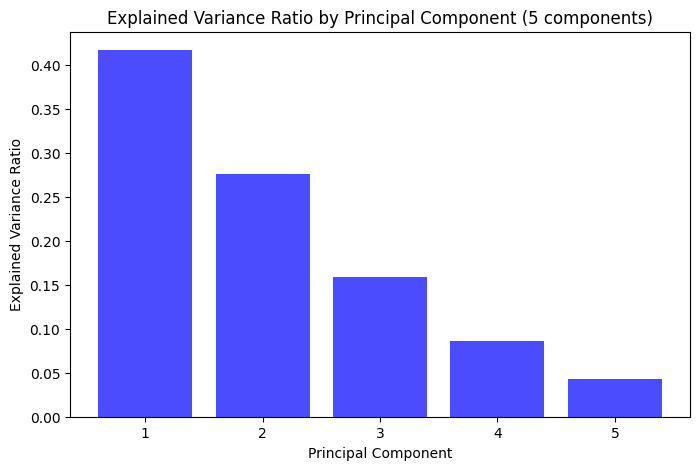

In [9]:
# Initialize PCA with 5 components
pca_5 = rice_ml.PCA(n_components=5)
# Fit PCA to the scaled features and transform
pca_features_5 = pca_5.fit_transform(scaled_features)
# Display the explained variance ratio for each component
print("Explained Variance Ratio (5 components):", pca_5.explained_variance_ratio)

# Plot the variance explained by each component
plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), pca_5.explained_variance_ratio, alpha=0.7, color='blue')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by Principal Component (5 components)')
plt.xticks(range(1, 6))
plt.show()

Looking at our Explained Variance Ratios and barplot, we can see that PC1, PC2, and PC3 explain about 85% of the total variance. By eliminating PC4 and PC5, we reduce dimensionality and eliminate a lot of the extra variance that leads to noise and overfitting. Thus, we fit our data with 3 PCs and implement KMeans as described in the KMeans example notebook.  

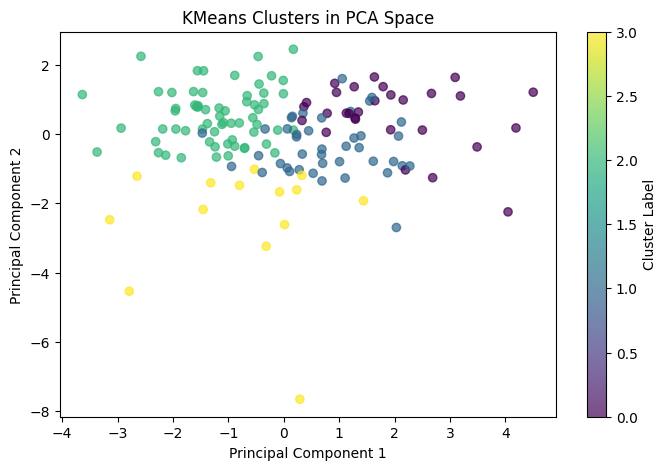

In [17]:
# Initialize PCA with 3 components
pca_3 = rice_ml.PCA(n_components=3)
# Fit PCA to the scaled features and transform
pca_features_3 = pca_3.fit_transform(scaled_features)

# Set seed to 42
np.random.seed(42)

# Initialize KMeans with 4 clusters and a maximum of 100 iterations
kmeans = rice_ml.KMeans(k=4, max_iter=100)

# Fit KMeans to the scaled features
kmeans.fit(pca_features_3)

# Plot the clusters in PC1 and PC2 space
plt.figure(figsize=(8, 5))
plt.scatter(pca_features_3[:, 0], pca_features_3[:, 1], c=kmeans.labels_, cmap='viridis', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('KMeans Clusters in PCA Space')
plt.colorbar(label='Cluster Label')
plt.show()

From the figure above, it appears that PC1 and PC2 are the primary differentiators between clusters 2 and 3. Clusters 0 and 1 are separate from 2 and 3, but have significant overlap with each other. PC3 likely accounts for this overlap. Additionally, we can say that clusters 2 and 3 are very distinct from the others, while clusters 0 and 1 likely share a lot of traits.

To inspect our clusters, and what they could mean, we assign labels to the players in our dataset and see if we notice any patterns.

In [16]:
# Assign cluster labels to the original features DataFrame
features["Cluster"] = kmeans.labels_

# Break down features by cluster
cluster_0 = features[features["Cluster"] == 0]
cluster_1 = features[features["Cluster"] == 1]
cluster_2 = features[features["Cluster"] == 2]
cluster_3 = features[features["Cluster"] == 3]

# Print table of feature means for each cluster
print("Cluster 0 Means:")
print(cluster_0[["height", "weight", "YPR", "YAC/REC", "ADOT", "CTR"]].mean())
print("\nCluster 1 Means:")
print(cluster_1[["height", "weight", "YPR", "YAC/REC", "ADOT", "CTR"]].mean())
print("\nCluster 2 Means:")
print(cluster_2[["height", "weight", "YPR", "YAC/REC", "ADOT", "CTR"]].mean())
print("\nCluster 3 Means:")
print(cluster_3[["height", "weight", "YPR", "YAC/REC", "ADOT", "CTR"]].mean())

# Print table of 5 players for each cluster
print("\nCluster 0:")
print(cluster_0[["Name", "height", "weight", "YPR", "YAC/REC", "ADOT", "CTR"]].head(5))
print("\nCluster 1:")
print(cluster_1[["Name", "height", "weight", "YPR", "YAC/REC", "ADOT", "CTR"]].head(5))
print("\nCluster 2:")
print(cluster_2[["Name", "height", "weight", "YPR", "YAC/REC", "ADOT", "CTR"]].head(5))
print("\nCluster 3:")
print(cluster_3[["Name", "height", "weight", "YPR", "YAC/REC", "ADOT", "CTR"]].head(5))

Cluster 0 Means:
height      71.172414
weight     194.689655
YPR         10.720690
YAC/REC      5.710345
ADOT         7.620690
CTR          0.132226
dtype: float64

Cluster 1 Means:
height      71.000000
weight     184.634146
YPR         11.946341
YAC/REC      3.575610
ADOT        12.521951
CTR          0.200431
dtype: float64

Cluster 2 Means:
height      74.698413
weight     211.365079
YPR         12.680952
YAC/REC      3.242857
ADOT        12.530159
CTR          0.260257
dtype: float64

Cluster 3 Means:
height      72.714286
weight     193.357143
YPR         18.921429
YAC/REC      5.228571
ADOT        17.407143
CTR          0.261233
dtype: float64

Cluster 0:
                   Name  height  weight   YPR  YAC/REC  ADOT       CTR
15         Stefon Diggs    72.0   191.0  11.7      4.1   9.1  0.125984
31        Kalif Raymond    68.0   180.0  12.0      6.8   6.3  0.100000
40  JuJu Smith-Schuster    73.0   215.0  10.6      5.7   6.0  0.173913
42          Cooper Kupp    74.0   205.0  11.8

Looking at these clusters, we see moderate differences in how the cluster means are distributed. Overall, the same general trends from the regular KMeans seem to hold. However, some of the cluster means are more extreme, allowing for better segmentation of player prototypes. 

Looking at the 5 example players we extracted from each cluster, we can identify what type of player is in each cluster. We believe that these clusters, while unexpected, do provide very interesting insights into the types of WRs in football. 

- **Cluster 0** is clearly the **YAC-heavy Slot WR**. They are marked by low ADOT and high YAC. All five of the players we show from that category can be confidently set in that role. 

- **Cluster 1** is the **smaller possesion WRs**. They may lineup in the Slot or Outside. They have a moderate amount of contested targets, are asked to run varyng route depths, and do not get a lot of YAC.  

- **Cluster 2** are **larger posession WRs**. Some are route runners and others are jump-ball threats. All of them are larger players who get a lot of contested catches and not a lot of YAC. 

- **Cluster 3** makes up our **speedsters and deep threats**. They have very high ADOTs and YAC from catching deep passes and burning defenders. Due to the nature of deep targets, many of their targets are also contested. 

Subjectively, the only cluster potentially worth splitting up is cluster 2. We believe that there is a significant difference in the playstyle of route-running possesion WRs and jump-ball posession WRs. Other than that, we feel that PCA did a very good job of aiding the clustering, and this model is much better than the initial KNN model. 